In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [4]:
df=pd.read_csv("gene_expression.csv")

In [5]:
df.head()

,Gene One,Gene Two,Cancer Present
0,4.3,3.9,1
1,2.5,6.3,0
2,5.7,3.9,1
3,6.1,6.2,0
4,7.4,3.4,1


(4.0, 8.0)

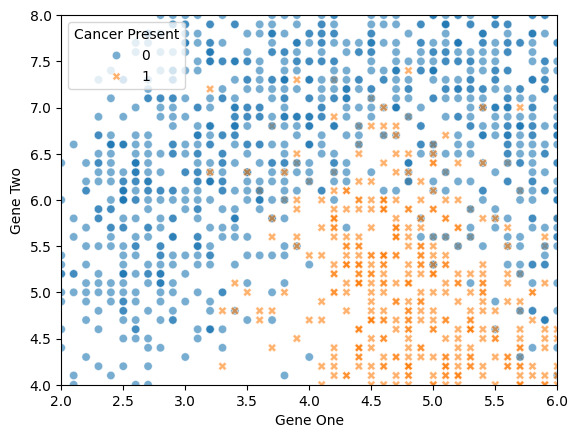

In [13]:
sns.scatterplot(data=df,x='Gene One',y='Gene Two',hue='Cancer Present',alpha=0.6,style='Cancer Present')

plt.xlim(2,6)
plt.ylim(4,8)

In [9]:
len(df)

3000

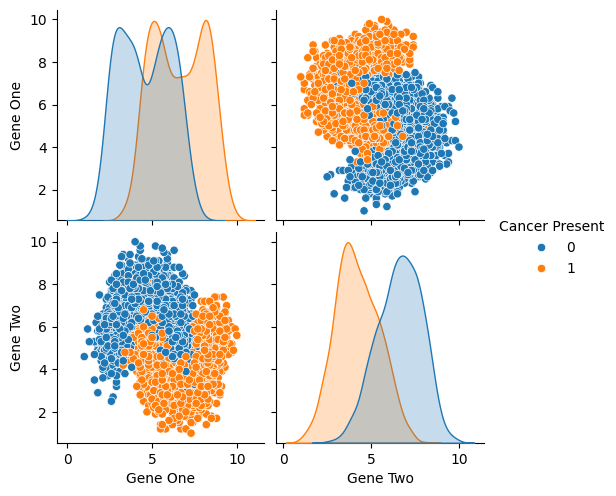

In [14]:
sns.pairplot(data=df,hue='Cancer Present')

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
from sklearn.preprocessing import StandardScaler

In [17]:
X=df.drop('Cancer Present',axis=1)

In [18]:
y=df['Cancer Present']

In [19]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [20]:
scaler=StandardScaler()

In [21]:
scaled_X_train=scaler.fit_transform(X_train)

In [23]:
scaled_X_test=scaler.transform(X_test)

In [26]:
from sklearn.neighbors import KNeighborsClassifier

In [28]:
knn_model=KNeighborsClassifier(n_neighbors=1)

In [30]:
knn_model.fit(scaled_X_train,y_train)

,n_neighbors,1
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [31]:
y_pred=knn_model.predict(scaled_X_test)

In [32]:
from sklearn.metrics import confusion_matrix,classification_report

In [33]:
len(y_test)

900

In [34]:
confusion_matrix(y_test,y_pred)

array([[426,  44],
       [ 45, 385]])

In [35]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.90      0.91      0.91       470
           1       0.90      0.90      0.90       430

    accuracy                           0.90       900
   macro avg       0.90      0.90      0.90       900
weighted avg       0.90      0.90      0.90       900



In [37]:
from sklearn.metrics import accuracy_score

In [39]:
accuracy=accuracy_score(y_test,y_pred)

In [40]:
1-accuracy

0.09888888888888892

In [43]:
#How we choose the 'k'
#PIPELINE.
test_error_rates=[]
for k in range(1,30):
    knn_model=KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(scaled_X_train,y_train)

    y_pred_test=knn_model.predict(scaled_X_test)
    test_error=1-accuracy_score(y_test,y_pred_test)

    test_error_rates.append(test_error)

In [44]:
test_error_rates

[0.09888888888888892,
 0.09777777777777774,
 0.07333333333333336,
 0.0755555555555556,
 0.07222222222222219,
 0.06444444444444442,
 0.06444444444444442,
 0.061111111111111116,
 0.05777777777777782,
 0.06222222222222218,
 0.061111111111111116,
 0.06000000000000005,
 0.061111111111111116,
 0.06222222222222218,
 0.05888888888888888,
 0.05777777777777782,
 0.05666666666666664,
 0.05555555555555558,
 0.05222222222222217,
 0.053333333333333344,
 0.054444444444444406,
 0.05111111111111111,
 0.054444444444444406,
 0.054444444444444406,
 0.05666666666666664,
 0.05555555555555558,
 0.05555555555555558,
 0.05777777777777782,
 0.05666666666666664]

Text(0, 0.5, 'Error Rate')

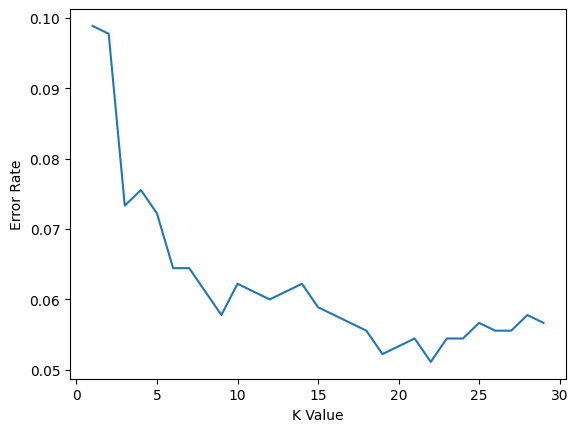

In [45]:
import matplotlib.pyplot as plt

plt.plot(range(1,30), test_error_rates)
plt.xlabel("K Value")
plt.ylabel("Error Rate")

In [ ]:
#PIPELINE--> GRID SEARCH CV

In [46]:
scaler=StandardScaler()

In [47]:
knn=KNeighborsClassifier()

In [48]:
operations=[('scaler',scaler),('knn',knn)]

In [49]:
from sklearn.pipeline import Pipeline

In [51]:
pipe=Pipeline(operations)

In [53]:
from sklearn.model_selection import GridSearchCV

In [55]:
k_values=list(range(1,20))

In [57]:
param_grid={'knn__n_neighbors':k_values}

In [58]:
full_cv_Classifier=GridSearchCV(pipe,param_grid,cv=5,scoring='accuracy')

In [59]:
full_cv_Classifier.fit(X_train,y_train)

,estimator,Pipeline(step...lassifier())])
,param_grid,"{'knn__n_neighbors': [1, 2, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [60]:
full_pred=full_cv_Classifier.predict(X_test)

In [61]:
print(classification_report(y_test,full_pred))

              precision    recall  f1-score   support

           0       0.94      0.96      0.95       470
           1       0.95      0.93      0.94       430

    accuracy                           0.94       900
   macro avg       0.94      0.94      0.94       900
weighted avg       0.94      0.94      0.94       900



In [62]:
new_patient=[[3.8,6.4]]

In [63]:
full_cv_Classifier.predict(new_patient)

C:\Users\Kirat\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([0])